In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv("diabetes.csv")

In [5]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [8]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [9]:
# Check for and remove duplicate rows
initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
duplicates_removed = initial_rows - df.shape[0]
print(f"\nNumber of duplicate rows removed: {duplicates_removed}")


Number of duplicate rows removed: 0


In [10]:
df['Age'].describe()

count    768.000000
mean      33.240885
std       11.760232
min       21.000000
25%       24.000000
50%       29.000000
75%       41.000000
max       81.000000
Name: Age, dtype: float64

In [11]:
df['Outcome'].describe()

count    768.000000
mean       0.348958
std        0.476951
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        1.000000
Name: Outcome, dtype: float64

In [13]:
df.groupby('BMI')['Outcome'].mean()

BMI
0.0     0.181818
18.2    0.000000
18.4    0.000000
19.1    0.000000
19.3    0.000000
          ...   
53.2    1.000000
55.0    1.000000
57.3    0.000000
59.4    1.000000
67.1    1.000000
Name: Outcome, Length: 248, dtype: float64

In [15]:
df.groupby('BMI')['Outcome'].describe()

,count,mean,std,min,25%,50%,75%,max
BMI,,,,,,,,
0.0,11.0,0.181818,0.40452,0.0,0.0,0.0,0.0,1.0
18.2,3.0,0.000000,0.00000,0.0,0.0,0.0,0.0,0.0
18.4,1.0,0.000000,NaN,0.0,0.0,0.0,0.0,0.0
19.1,1.0,0.000000,NaN,0.0,0.0,0.0,0.0,0.0
19.3,1.0,0.000000,NaN,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
53.2,1.0,1.000000,NaN,1.0,1.0,1.0,1.0,1.0
55.0,1.0,1.000000,NaN,1.0,1.0,1.0,1.0,1.0
57.3,1.0,0.000000,NaN,0.0,0.0,0.0,0.0,0.0


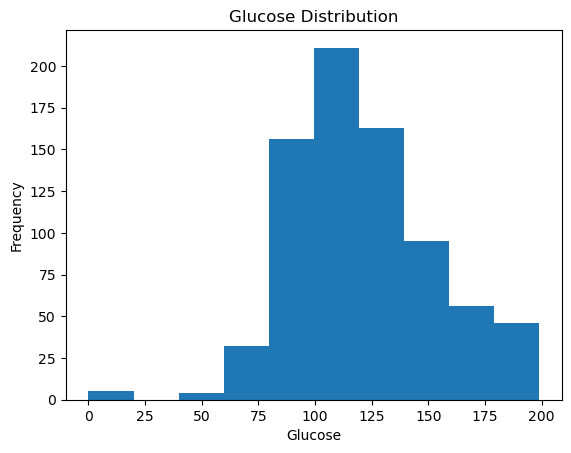

In [20]:
# Histogram- Glucose

plt.hist(df['Glucose'], bins=10)
plt.title("Glucose Distribution")
plt.xlabel("Glucose")
plt.ylabel("Frequency")
plt.show()

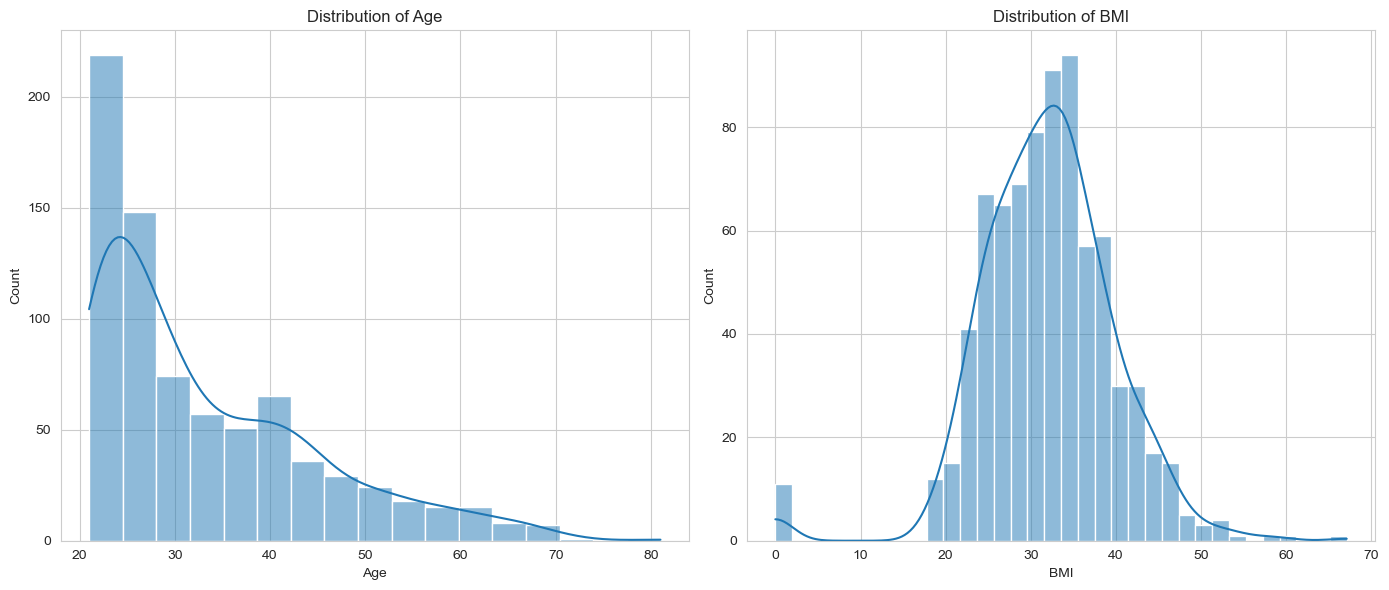

In [100]:
# Set style for plots
sns.set_style('whitegrid')

# 2. Histograms for numerical features
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['Age'], kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.histplot(df['BMI'], kde=True)
plt.title('Distribution of BMI')
plt.xlabel('BMI')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

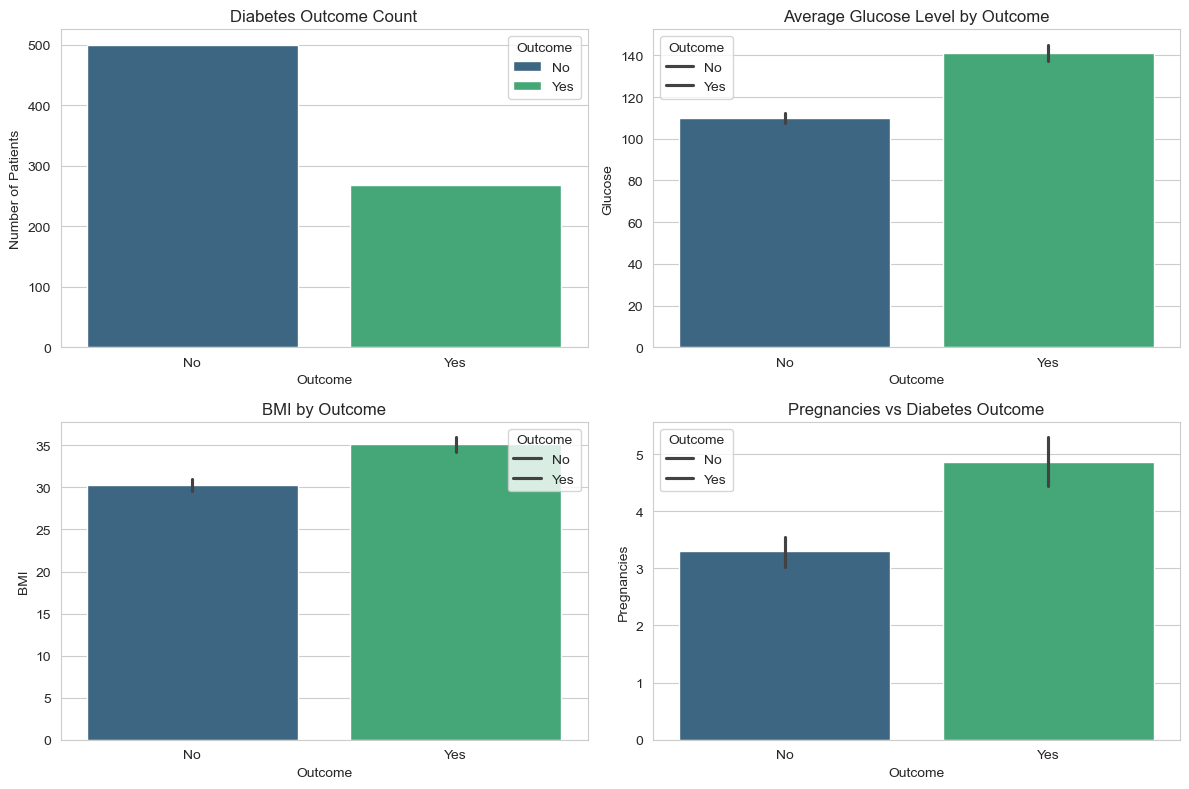

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
sns.countplot(data=df, x='Outcome', hue="Outcome", palette='viridis')
plt.title("Diabetes Outcome Count")
plt.xlabel("Outcome")
plt.ylabel("Number of Patients")
plt.legend(title='Outcome',labels=['No','Yes'])
plt.xticks([0,1], ['No','Yes'])

plt.subplot(2,2,2)
sns.barplot(data=df, x='Outcome', y='Glucose', hue="Outcome",palette='viridis')
plt.title("Average Glucose Level by Outcome")
plt.legend(title='Outcome',labels=['No','Yes'])
plt.xticks([0,1], ['No','Yes'])

plt.subplot(2,2,3)
sns.barplot(data=df, x='Outcome', y='BMI', hue="Outcome", palette='viridis')
plt.title("BMI by Outcome")
plt.legend(title='Outcome',labels=['No','Yes'])
plt.xticks([0,1], ['No','Yes'])

plt.subplot(2,2,4)
sns.barplot(data=df, x='Outcome', y='Pregnancies', hue="Outcome", palette='viridis')
plt.title("Pregnancies vs Diabetes Outcome")
plt.legend(title='Outcome',labels=['No','Yes'])
plt.xticks([0,1], ['No','Yes'])

plt.tight_layout()
plt.show()

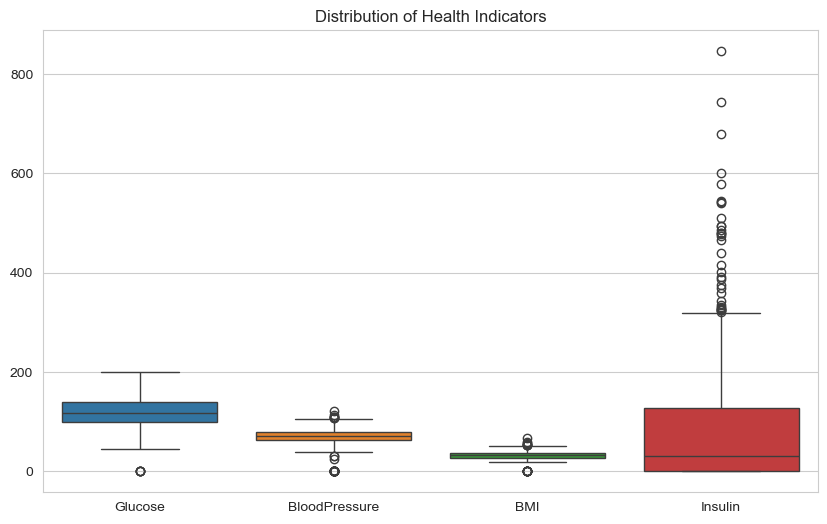

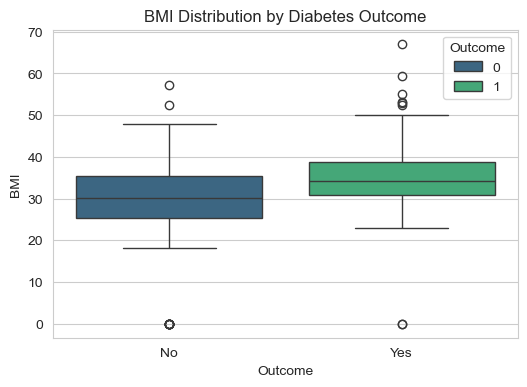

In [80]:
# Box Plot

plt.figure(figsize=(10,6))

sns.boxplot(data=df[['Glucose','BloodPressure','BMI','Insulin']])

plt.title("Distribution of Health Indicators")
plt.show()



plt.figure(figsize=(6,4))

sns.boxplot(data=df, x='Outcome', y='BMI', hue='Outcome', palette='viridis')

plt.title("BMI Distribution by Diabetes Outcome")
plt.xlabel("Outcome")
plt.ylabel("BMI")
plt.xticks([0,1], ['No','Yes'])

plt.show()

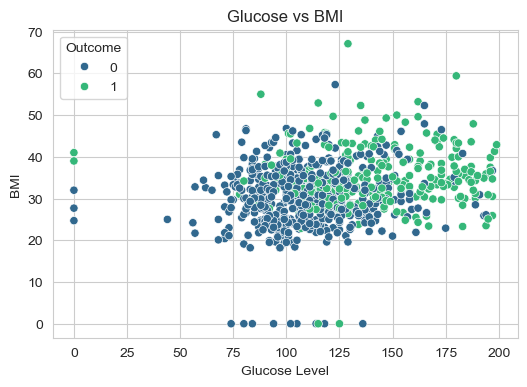

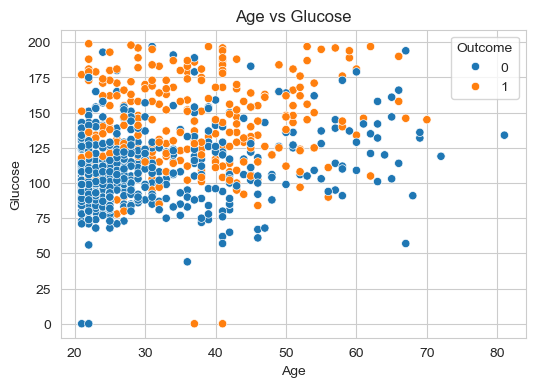

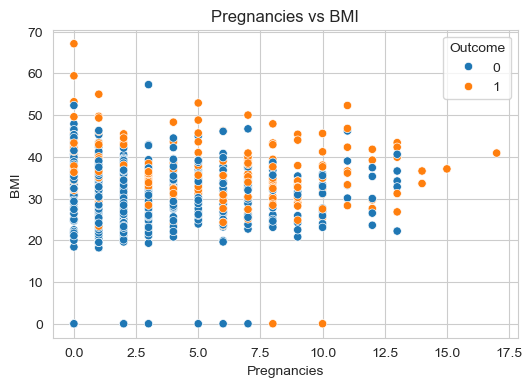

In [96]:
#Scatter plot

plt.figure(figsize=(6,4))

sns.scatterplot(data=df, x='Glucose', y='BMI', hue='Outcome', palette='viridis')
plt.title("Glucose vs BMI")
plt.xlabel("Glucose Level")
plt.ylabel("BMI")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='Age', y='Glucose', hue='Outcome')
plt.title("Age vs Glucose")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='Pregnancies', y='BMI', hue='Outcome')
plt.title("Pregnancies vs BMI")
plt.show()

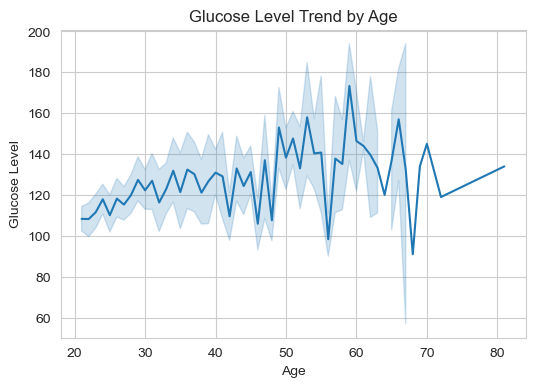

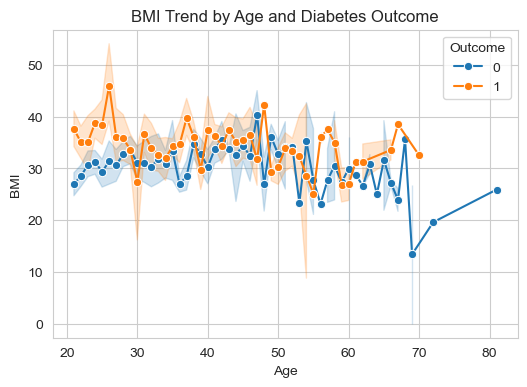

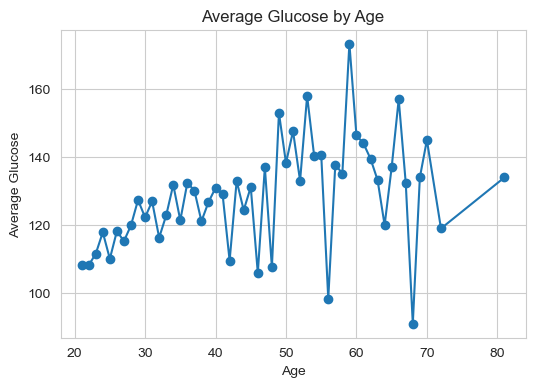

In [90]:
# Line chart

plt.figure(figsize=(6,4))

sns.lineplot(data=df, x='Age', y='Glucose')

plt.title("Glucose Level Trend by Age")
plt.xlabel("Age")
plt.ylabel("Glucose Level")

plt.show()

plt.figure(figsize=(6,4))

sns.lineplot(data=df, x='Age', y='BMI', hue='Outcome', marker='o')

plt.title("BMI Trend by Age and Diabetes Outcome")
plt.xlabel("Age")
plt.ylabel("BMI")

plt.show()

plt.figure(figsize=(6,4))

df.groupby('Age')['Glucose'].mean().plot(kind='line', marker='o')

plt.title("Average Glucose by Age")
plt.xlabel("Age")
plt.ylabel("Average Glucose")

plt.show()

In [91]:
# Correlation
corr = df.corr()
print(corr)

                          Pregnancies   Glucose  BloodPressure  SkinThickness  \
Pregnancies                  1.000000  0.129459       0.141282      -0.081672   
Glucose                      0.129459  1.000000       0.152590       0.057328   
BloodPressure                0.141282  0.152590       1.000000       0.207371   
SkinThickness               -0.081672  0.057328       0.207371       1.000000   
Insulin                     -0.073535  0.331357       0.088933       0.436783   
BMI                          0.017683  0.221071       0.281805       0.392573   
DiabetesPedigreeFunction    -0.033523  0.137337       0.041265       0.183928   
Age                          0.544341  0.263514       0.239528      -0.113970   
Outcome                      0.221898  0.466581       0.065068       0.074752   

                           Insulin       BMI  DiabetesPedigreeFunction  \
Pregnancies              -0.073535  0.017683                 -0.033523   
Glucose                   0.331357  0.221

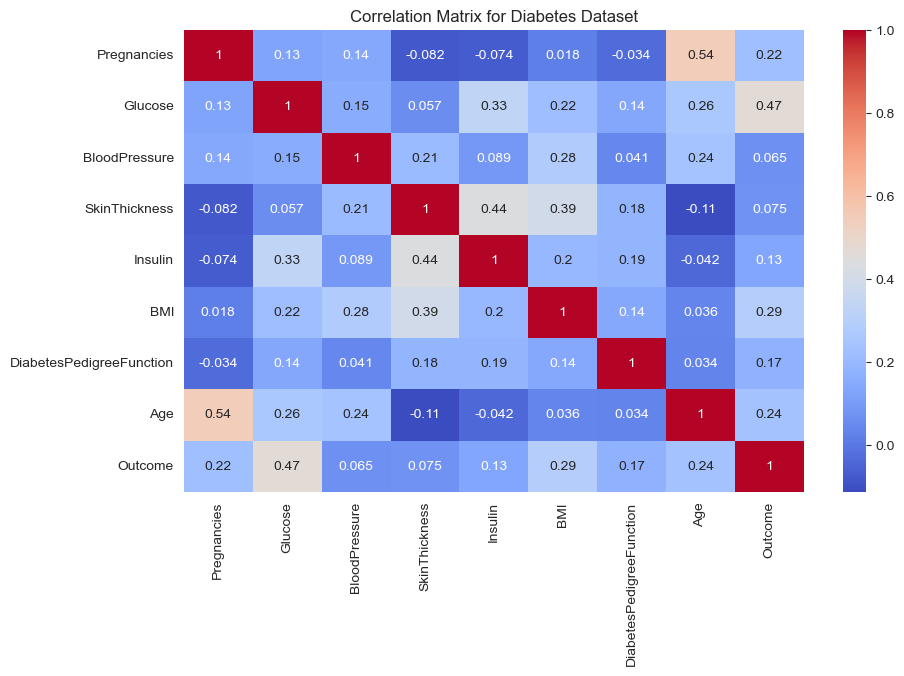

In [92]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Matrix for Diabetes Dataset")

plt.show()